In [1]:
import pandas as pd
# import sys
# sys.path.append("../Handlers")
# import url_preprocessing

Record of urls after cleaning (missing Urls, invalid Urls, duplicate Urls):

Starting URL dataset cleanup...

Removed 0 rows with missing URLs

Removed 13 invalid URLs

Removed 17288 duplicate URLs

Cleanup completed!

Original count: 651191

Final count: 633889

Total removed: 17302

In [2]:
# df.to_csv("./malicious_phish_cleaned.csv")

<code>df = pd.read_csv("./malicious_phish_cleaned.csv")</code>

<code>df = url_preprocessing.extract_url_features()</code>

<code>df.to_csv("./malicious_phish_preprocessed.csv")</code>

In [2]:
df = pd.read_csv("./malicious_phish_preprocessed.csv")

benign        422930
defacement     94915
phishing       92405
malware        23639
Name: type, dtype: int64


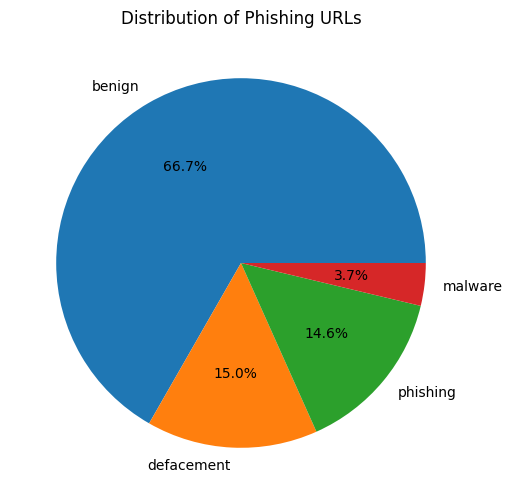

In [6]:
import matplotlib.pyplot as plt
import os

# Four types: benign, phishing, defacement and malware
label_counts = df['type'].value_counts()

print(label_counts)

plt.figure(figsize=(10, 6))
plt.pie(label_counts.values, labels=["benign", "defacement", "phishing", "malware"], autopct='%1.1f%%')
plt.title('Distribution of Phishing URLs')
plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
plt.show()

In [4]:
X = df.drop(columns=["Unnamed: 0", "url", "type"])
y = df["type"]
del df

In [5]:
X = pd.get_dummies(X, columns=["tld"], drop_first=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
# from multiclass_traintest import train_and_evaluate_models

# metric_results = []

# train_and_evaluate_models(X, y, "Malicious_Phish", metric_results, threading=True, max_workers=4)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
lr = LogisticRegression(multi_class="multinomial")

In [10]:
lr.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [11]:
y_pred = lr.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

del lr

              precision    recall  f1-score   support

           0       0.72      0.91      0.81     84729
           1       0.55      0.13      0.21     18909
           2       0.00      0.00      0.00      4761
           3       0.47      0.40      0.44     18379

    accuracy                           0.69    126778
   macro avg       0.44      0.36      0.36    126778
weighted avg       0.63      0.69      0.63    126778



e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [12]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

sgd = OneVsRestClassifier(LinearSVC(), n_jobs=3)
sgd.fit(X_train, y_train)

OneVsRestClassifier(estimator=LinearSVC(), n_jobs=3)

In [13]:
y_pred = sgd.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

del sgd

              precision    recall  f1-score   support

           0       0.71      0.97      0.82     84729
           1       0.83      0.37      0.51     18909
           2       0.24      0.02      0.03      4761
           3       0.31      0.05      0.08     18379

    accuracy                           0.71    126778
   macro avg       0.52      0.35      0.36    126778
weighted avg       0.65      0.71      0.64    126778



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=3)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=3)

In [15]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

del rf

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     84729
           1       0.94      0.91      0.92     18909
           2       0.97      0.92      0.95      4761
           3       0.88      0.85      0.87     18379

    accuracy                           0.94    126778
   macro avg       0.94      0.91      0.92    126778
weighted avg       0.94      0.94      0.94    126778



In [16]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred))

del dt

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     84729
           1       0.89      0.91      0.90     18909
           2       0.94      0.94      0.94      4761
           3       0.86      0.86      0.86     18379

    accuracy                           0.93    126778
   macro avg       0.91      0.91      0.91    126778
weighted avg       0.93      0.93      0.93    126778



In [18]:
from sklearn.ensemble import ExtraTreesClassifier

xt = ExtraTreesClassifier(n_jobs=3)
xt.fit(X_train, y_train)

ExtraTreesClassifier(n_jobs=3)

In [19]:
y_pred = xt.predict(X_test)

print(classification_report(y_test, y_pred))

del xt

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     84729
           1       0.94      0.88      0.91     18909
           2       0.97      0.91      0.94      4761
           3       0.87      0.83      0.85     18379

    accuracy                           0.93    126778
   macro avg       0.93      0.90      0.91    126778
weighted avg       0.93      0.93      0.93    126778



In [22]:
from sklearn.linear_model import Perceptron

p = OneVsRestClassifier(Perceptron(n_jobs=2), n_jobs=2)
p.fit(X_train, y_train)

OneVsRestClassifier(estimator=Perceptron(n_jobs=2), n_jobs=2)

In [23]:
y_pred = p.predict(X_test)

print(classification_report(y_test, y_pred))

del p

              precision    recall  f1-score   support

           0       0.67      0.99      0.80     84729
           1       0.40      0.04      0.07     18909
           2       0.00      0.00      0.00      4761
           3       0.00      0.00      0.00     18379

    accuracy                           0.67    126778
   macro avg       0.27      0.26      0.22    126778
weighted avg       0.51      0.67      0.54    126778



e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Python Tests\AI\.venv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [24]:
from sklearn.linear_model import PassiveAggressiveClassifier

pa = OneVsRestClassifier(PassiveAggressiveClassifier(n_jobs=2), n_jobs=2)
pa.fit(X_train, y_train)

OneVsRestClassifier(estimator=PassiveAggressiveClassifier(n_jobs=2), n_jobs=2)

In [25]:
y_pred = pa.predict(X_test)

print(classification_report(y_test, y_pred))

del pa

              precision    recall  f1-score   support

           0       0.71      0.96      0.82     84729
           1       0.69      0.44      0.54     18909
           2       0.41      0.06      0.11      4761
           3       0.44      0.00      0.00     18379

    accuracy                           0.71    126778
   macro avg       0.57      0.36      0.36    126778
weighted avg       0.66      0.71      0.63    126778



In [26]:
from sklearn.naive_bayes import BernoulliNB

nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

In [27]:
y_pred = nb.predict(X_test)

print(classification_report(y_test, y_pred))

del nb

              precision    recall  f1-score   support

           0       0.79      0.81      0.80     84729
           1       0.49      0.71      0.58     18909
           2       0.91      0.63      0.75      4761
           3       0.40      0.19      0.26     18379

    accuracy                           0.70    126778
   macro avg       0.65      0.59      0.60    126778
weighted avg       0.69      0.70      0.69    126778

